In [80]:
import psycopg2
import pandas as pd
from sqlalchemy import create_engine, text

In [ ]:
conn = psycopg2.connect(
    host='localhost',
    user='postgres',
    password='--hidden--',
    dbname='sqlda',
    port=5432
)

In [82]:
cur = conn.cursor()
cur.execute("SELECT * FROM customers LIMIT 2")
records = cur.fetchall()
print(records)

[(716, None, 'Jarred', 'Bester', None, 'jbesterjv@nih.gov', 'M', '216.51.110.28', None, None, None, None, None, None, None, datetime.datetime(2021, 9, 19, 0, 0)), (644, None, 'Aeriell', 'Zanicchi', None, 'azanicchihv@a8.net', 'F', '154.245.228.134', None, None, None, None, None, None, None, datetime.datetime(2019, 4, 3, 0, 0))]


In [83]:
cnxn_string = (
    'postgresql+psycopg2://{username}:{pswd}@{host}:{port}/{database}'
)

In [ ]:
engine = create_engine(
    cnxn_string.format(
        username='postgres',
        pswd='--hidden--',
        host='localhost',
        port=5432,
        database='sqlda',
    )
)

In [85]:
with engine.connect() as conn:
    result = conn.execute(
        text('SELECT * FROM customers LIMIT 2')
    ).fetchall()

print(result)

[(716, None, 'Jarred', 'Bester', None, 'jbesterjv@nih.gov', 'M', '216.51.110.28', None, None, None, None, None, None, None, datetime.datetime(2021, 9, 19, 0, 0)), (644, None, 'Aeriell', 'Zanicchi', None, 'azanicchihv@a8.net', 'F', '154.245.228.134', None, None, None, None, None, None, None, datetime.datetime(2019, 4, 3, 0, 0))]


In [86]:
customers_data = pd.read_sql_table('customers', engine)

In [87]:
customers_data

,customer_id,title,first_name,last_name,suffix,email,gender,ip_address,phone,street_address,city,state,postal_code,latitude,longitude,date_added
0,716,None,Jarred,Bester,None,jbesterjv@nih.gov,M,216.51.110.28,None,None,None,None,None,NaN,NaN,2021-09-19
1,644,None,Aeriell,Zanicchi,None,azanicchihv@a8.net,F,154.245.228.134,None,None,None,None,None,NaN,NaN,2019-04-03
2,709,None,Chane,McGrory,None,cmcgroryjo@gravatar.com,M,182.125.205.96,None,None,None,None,None,NaN,NaN,2022-07-02
3,1097,None,Edita,Bein,None,ebeinug@blog.com,F,20.238.148.141,504-467-1751,None,None,None,None,NaN,NaN,2020-06-16
4,1194,None,Alford,Cartwright,None,acartwrightx5@shop-pro.jp,M,6.64.226.158,None,None,None,None,None,NaN,NaN,2022-05-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,None,Iseabal,Earlam,None,iearlam12kr@ebay.co.uk,F,140.155.219.82,318-518-7877,24 Westport Point,Shreveport,LA,71130,32.6076,-93.7526,2020-11-22
49996,49997,None,Juditha,Caisley,None,jcaisley12ks@1und1.de,F,83.57.155.38,None,0349 Bonner Avenue,Phoenix,AZ,85062,33.2765,-112.1872,2017-09-03
49997,49998,None,Chelsie,Plewman,None,cplewman12kt@shutterfly.com,F,79.164.27.32,847-854-2700,4 Aberg Crossing,Evanston,IL,60208,42.0586,-87.6845,2017-03-03
49998,49999,None,Danya,Wagon,None,dwagon12ku@hp.com,M,133.203.33.70,605-869-4255,1 Autumn Leaf Road,Sioux Falls,SD,57105,43.5240,-96.7341,2023-02-07


In [88]:
customers_data.head(5)

,customer_id,title,first_name,last_name,suffix,email,gender,ip_address,phone,street_address,city,state,postal_code,latitude,longitude,date_added
0,716,None,Jarred,Bester,None,jbesterjv@nih.gov,M,216.51.110.28,None,None,None,None,None,NaN,NaN,2021-09-19
1,644,None,Aeriell,Zanicchi,None,azanicchihv@a8.net,F,154.245.228.134,None,None,None,None,None,NaN,NaN,2019-04-03
2,709,None,Chane,McGrory,None,cmcgroryjo@gravatar.com,M,182.125.205.96,None,None,None,None,None,NaN,NaN,2022-07-02
3,1097,None,Edita,Bein,None,ebeinug@blog.com,F,20.238.148.141,504-467-1751,None,None,None,None,NaN,NaN,2020-06-16
4,1194,None,Alford,Cartwright,None,acartwrightx5@shop-pro.jp,M,6.64.226.158,None,None,None,None,None,NaN,NaN,2022-05-06


In [89]:
# Exercise 4.2: Reading, visualizing, and saving data in Python
from sqlalchemy import create_engine, text
import pandas as pd

In [ ]:
cnxn_string = (
    'postgresql+psycopg2://{username}:{pswd}@{host}:{port}/{database}'
)

engine = create_engine(
    cnxn_string.format(
        username='postgres',
        pswd='--hidden--',
        host='localhost',
        port=5432,
        database='sqlda'
    )
)

query = "SELECT * FROM customers"
customer_data = pd.read_sql_query(query, engine)
customer_data.head()

,customer_id,title,first_name,last_name,suffix,email,gender,ip_address,phone,street_address,city,state,postal_code,latitude,longitude,date_added
0,716,None,Jarred,Bester,None,jbesterjv@nih.gov,M,216.51.110.28,None,None,None,None,None,NaN,NaN,2021-09-19
1,644,None,Aeriell,Zanicchi,None,azanicchihv@a8.net,F,154.245.228.134,None,None,None,None,None,NaN,NaN,2019-04-03
2,709,None,Chane,McGrory,None,cmcgroryjo@gravatar.com,M,182.125.205.96,None,None,None,None,None,NaN,NaN,2022-07-02
3,1097,None,Edita,Bein,None,ebeinug@blog.com,F,20.238.148.141,504-467-1751,None,None,None,None,NaN,NaN,2020-06-16
4,1194,None,Alford,Cartwright,None,acartwrightx5@shop-pro.jp,M,6.64.226.158,None,None,None,None,None,NaN,NaN,2022-05-06


In [91]:
customer_per_state = (customer_data[['state', 'customer_id']]
                     .groupby('state').count()
                     )
customer_per_state

,customer_id
state,
AK,188
AL,922
AR,232
AZ,931
CA,5038
CO,1042
CT,576
DC,1447
DE,149


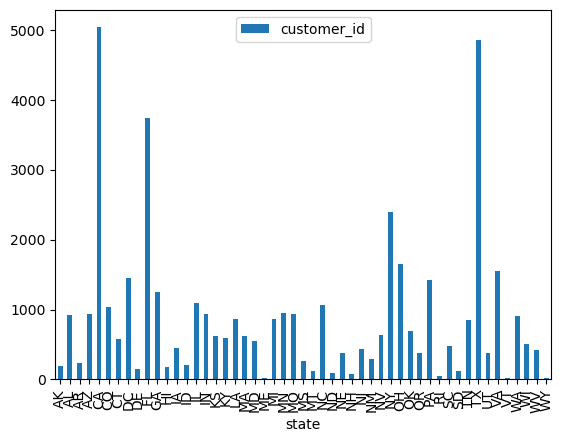

In [92]:
import matplotlib.pyplot as plt
customer_per_state.plot(kind='bar')
plt.show()

In [93]:
customer_per_state.to_sql(
    'customer_per_state', engine, if_exists='replace'
)

51

In [ ]:
# Activity 4
# connecting, selecting, and uploading the products where production started in 2024 to the SQLDA database

cnxn_string = ('postgresql+psycopg2://{username}:{pswd}@{host}:{port}/{database}')
engine = create_engine(
    cnxn_string.format(
        username='postgres',
        pswd='--hidden--',
        host='localhost',
        port=5432,
        database='sqlda'
    )
)


In [95]:
products_df = pd.read_sql_table('products', engine)
products_df

,product_id,model,year,product_type,base_msrp,production_start_date,production_end_date
0,1,Lemon,2016,scooter,399.99,2015-10-28,2018-02-03
1,2,Lemon Limited Edition,2017,scooter,799.99,2016-08-30,2016-11-24
2,3,Lemon,2019,scooter,499.99,2018-12-27,2024-08-24
3,5,Blade,2020,scooter,699.99,2020-02-17,2020-09-23
4,7,Bat,2022,scooter,599.99,2022-06-07,NaT
5,8,Bat Limited Edition,2023,scooter,699.99,2022-10-13,NaT
6,12,Lemon Zester,2025,scooter,349.99,2024-10-01,NaT
7,4,Model Chi,2020,automobile,115000.00,2020-02-17,2024-08-24
8,6,Model Sigma,2021,automobile,65500.00,2020-12-10,2024-05-28
9,9,Model Epsilon,2023,automobile,35000.00,2022-10-13,NaT


In [96]:
products_2024 = products_df[('2025-01-01' > products_df.production_start_date) & (products_df.production_start_date >= '2024-01-01')]
products_2024

,product_id,model,year,product_type,base_msrp,production_start_date,production_end_date
6,12,Lemon Zester,2025,scooter,349.99,2024-10-01,NaT
11,11,Model Chi,2025,automobile,95000.00,2024-10-01,NaT


In [97]:
products_2024.to_sql('products_2024', engine, if_exists='replace')

2